# EDA Salary Data

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
data = pd.read_csv("../data/raw/jobs.csv")
data.head(20)

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"
5,5,Data Scientist,$137K-$171K (Glassdoor est.),About Us:\n\nHeadquartered in beautiful Santa ...,4.2,HG Insights\n4.2,"Santa Barbara, CA","Santa Barbara, CA",51 to 200 employees,2010,Company - Private,Computer Hardware & Software,Information Technology,Unknown / Non-Applicable,-1
6,6,Data Scientist / Machine Learning Expert,$137K-$171K (Glassdoor est.),Posting Title\nData Scientist / Machine Learni...,3.9,Novartis\n3.9,"Cambridge, MA","Basel, Switzerland",10000+ employees,1996,Company - Public,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,$10+ billion (USD),-1
7,7,Data Scientist,$137K-$171K (Glassdoor est.),Introduction\n\nHave you always wanted to run ...,3.5,iRobot\n3.5,"Bedford, MA","Bedford, MA",1001 to 5000 employees,1990,Company - Public,Consumer Electronics & Appliances Stores,Retail,$1 to $2 billion (USD),-1
8,8,Staff Data Scientist - Analytics,$137K-$171K (Glassdoor est.),Intuit is seeking a Staff Data Scientist to co...,4.4,Intuit - Data\n4.4,"San Diego, CA","Mountain View, CA",5001 to 10000 employees,1983,Company - Public,Computer Hardware & Software,Information Technology,$2 to $5 billion (USD),"Square, PayPal, H&R Block"
9,9,Data Scientist,$137K-$171K (Glassdoor est.),Ready to write the best chapter of your career...,3.6,XSELL Technologies\n3.6,"Chicago, IL","Chicago, IL",51 to 200 employees,2014,Company - Private,Enterprise Software & Network Solutions,Information Technology,Unknown / Non-Applicable,-1


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              672 non-null    int64  
 1   Job Title          672 non-null    str    
 2   Salary Estimate    672 non-null    str    
 3   Job Description    672 non-null    str    
 4   Rating             672 non-null    float64
 5   Company Name       672 non-null    str    
 6   Location           672 non-null    str    
 7   Headquarters       672 non-null    str    
 8   Size               672 non-null    str    
 9   Founded            672 non-null    int64  
 10  Type of ownership  672 non-null    str    
 11  Industry           672 non-null    str    
 12  Sector             672 non-null    str    
 13  Revenue            672 non-null    str    
 14  Competitors        672 non-null    str    
dtypes: float64(1), int64(2), str(12)
memory usage: 78.9 KB


In [4]:
data.isnull().sum()

index                0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
dtype: int64

In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
df = data.drop(columns = ["index"])

## Conversion du cible de type object en type numérique

In [7]:
def clean_salary(salary_text):

    salary_text = salary_text.split('(')[0].replace('$', '').replace('K', '').replace(' ', '')
    try:
        if '-' in salary_text:
            low, high = salary_text.split('-')
            return (int(low) + int(high)) / 2
        return int(salary_text)
    except:
        return None

df['avg_salary'] = df['Salary Estimate'].apply(clean_salary)


  ## Analyse les variables numériques 

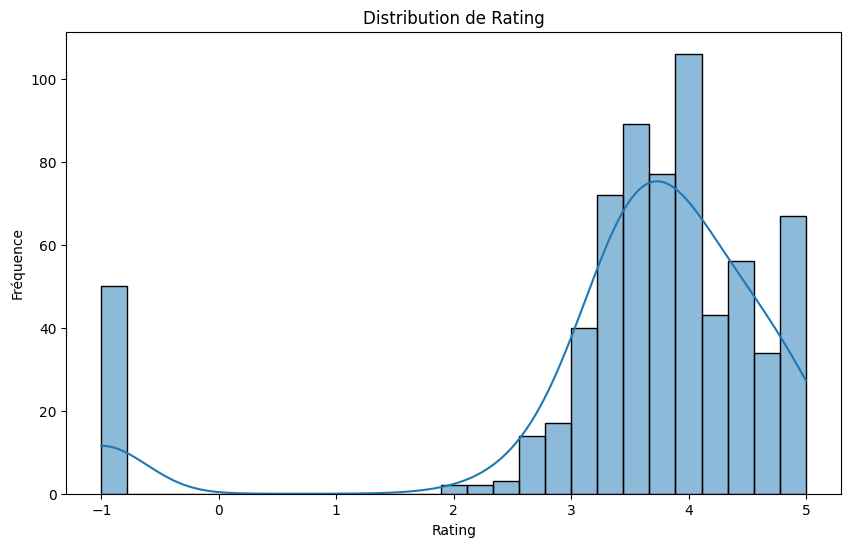

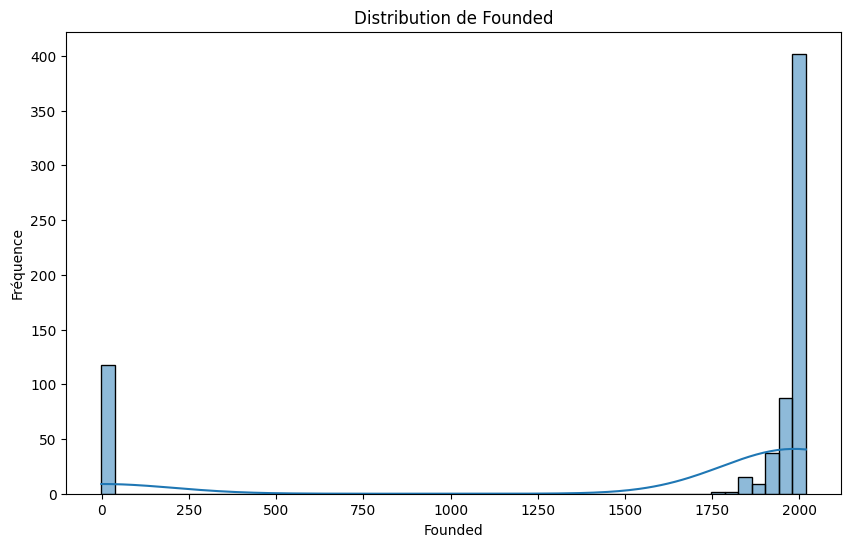

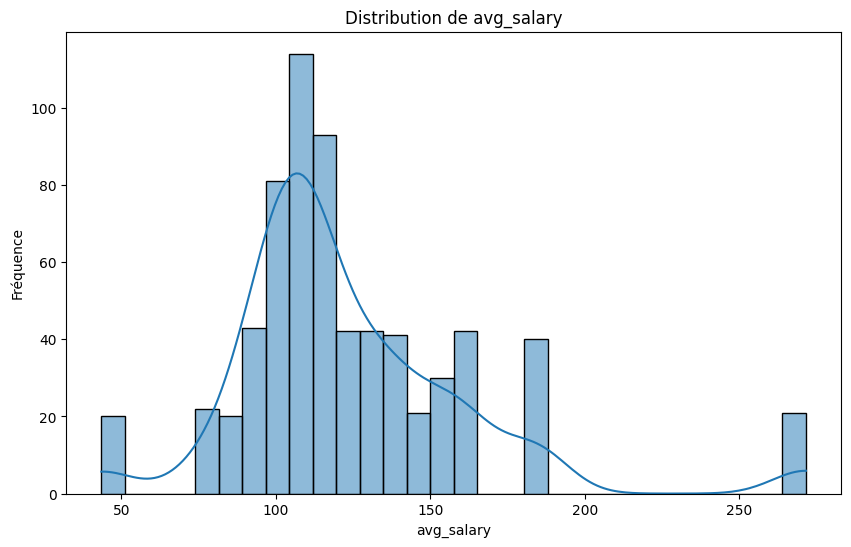

In [8]:
def plot_histogram(df):
  
  cols_num = df.select_dtypes(include=['number','float64']).columns.tolist()
  for col in cols_num:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')
    plt.show()

plot_histogram(df)

In [9]:
def plot_boxplot(df,cols):        
    
    for col in cols :
        plt.figure(figsize=(6, 10))
        sns.boxplot(y=df[col], color='#4C72B0', fliersize=5)
        plt.title(f'Analyse des Outliers : {col}', fontsize=14, fontweight='bold')
        plt.xlabel(f'Valeurs de {col}')
        plt.grid(axis='x', linestyle='--', alpha=0.7) 
        
        plt.show()

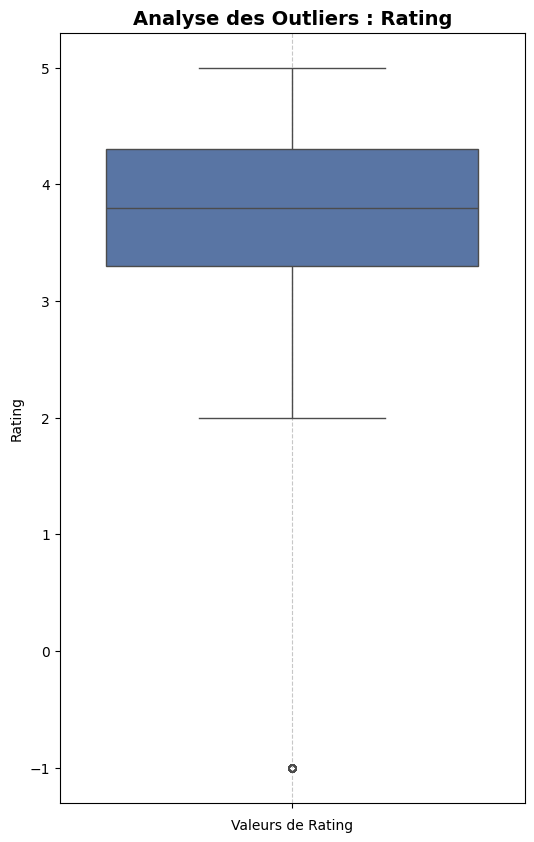

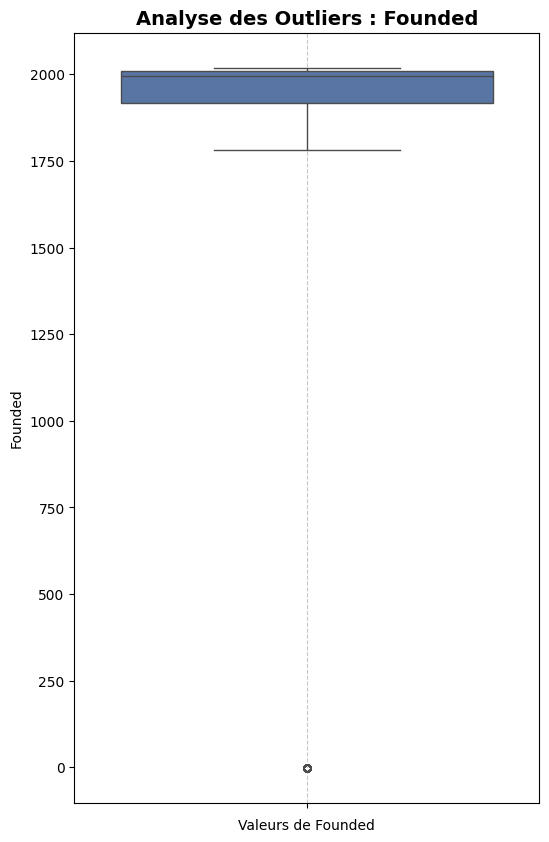

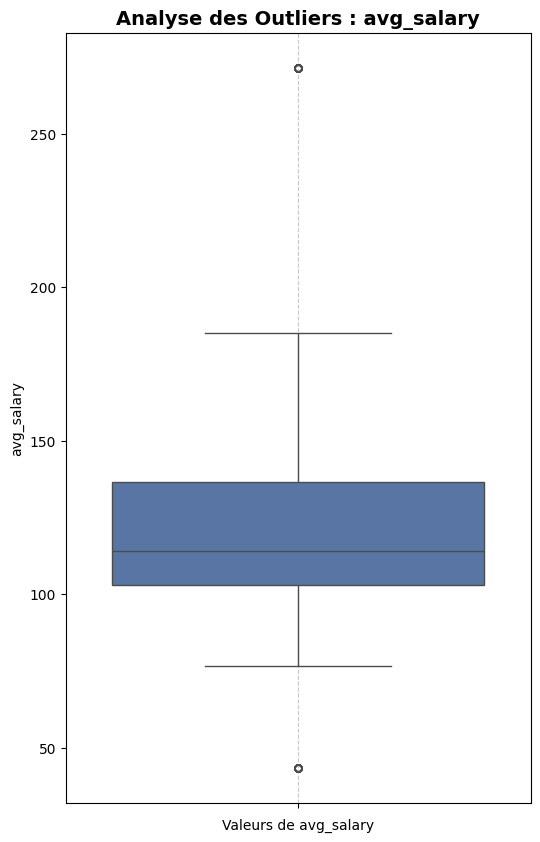

In [10]:
cols_num = df.select_dtypes(include=['number','float']).columns.tolist()
plot_boxplot(df, cols_num )

## Analyse les categorialles variables

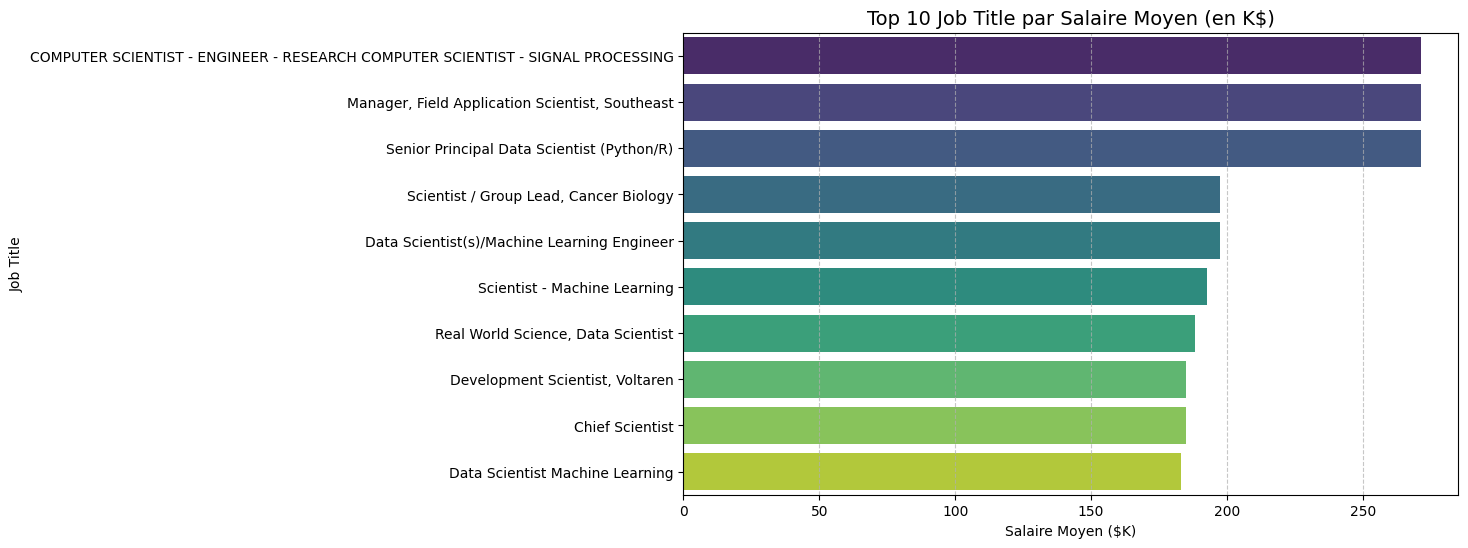

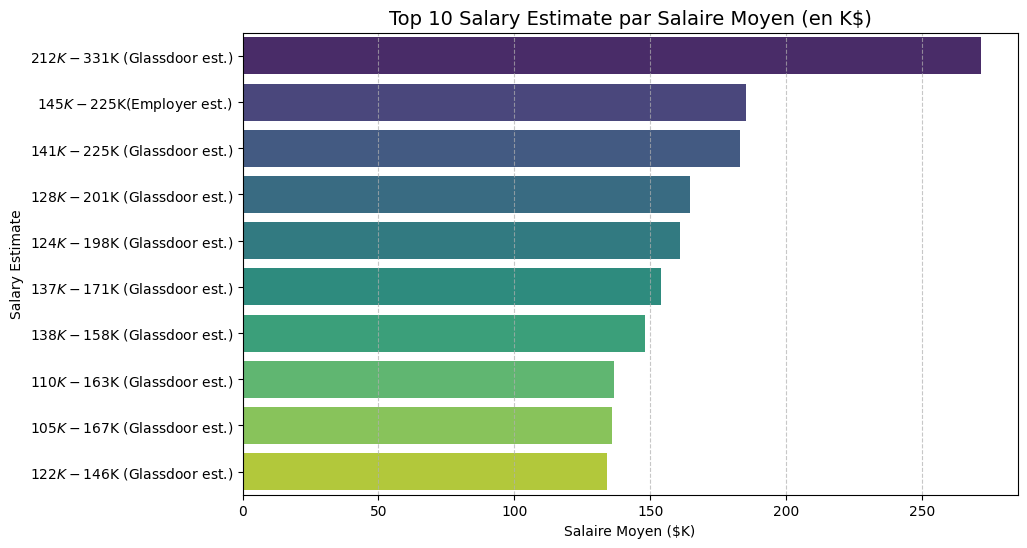

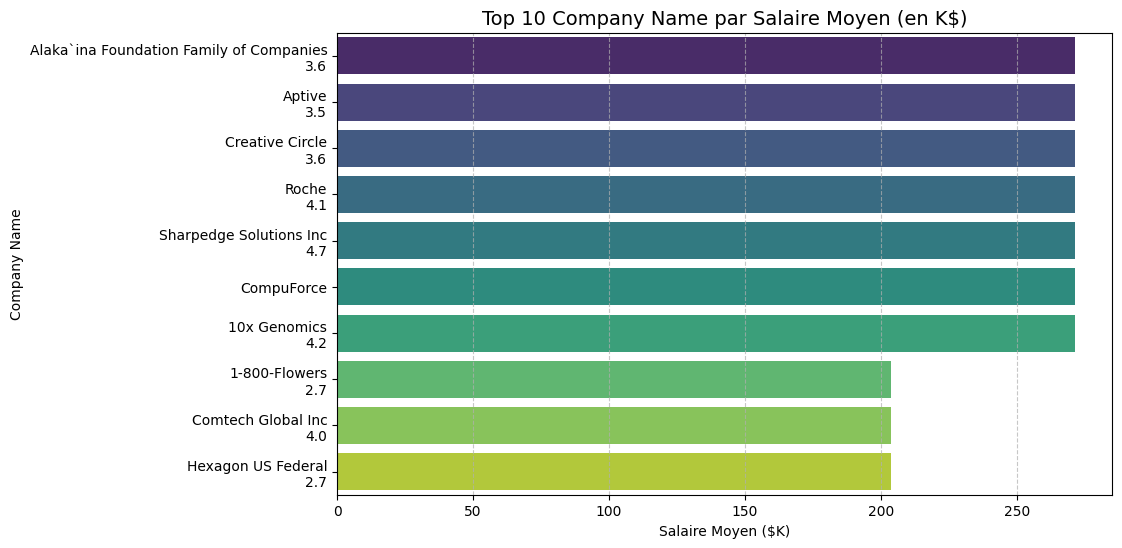

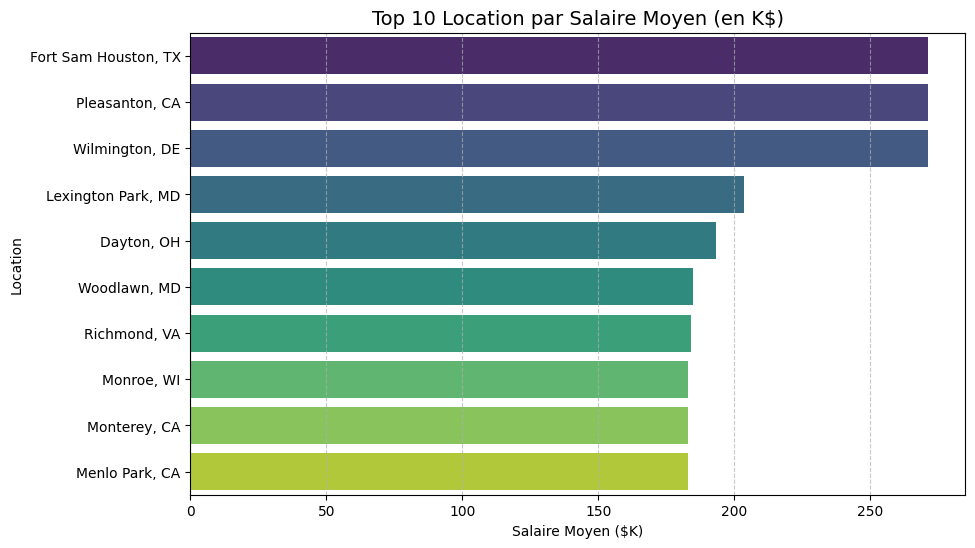

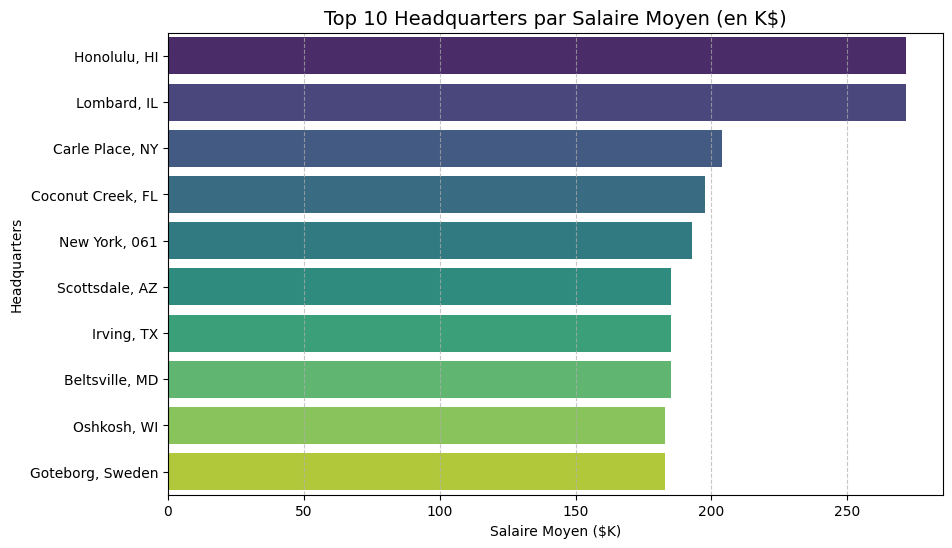

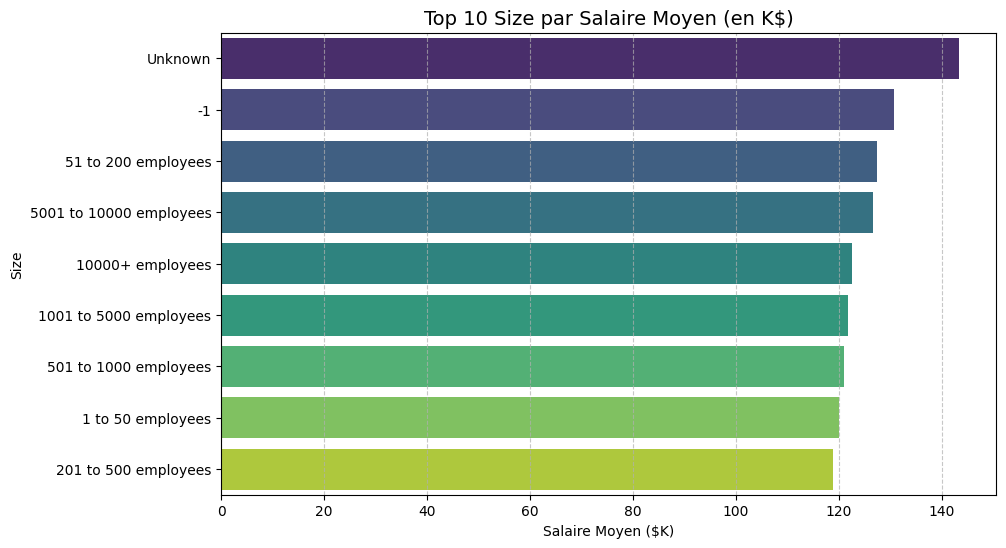

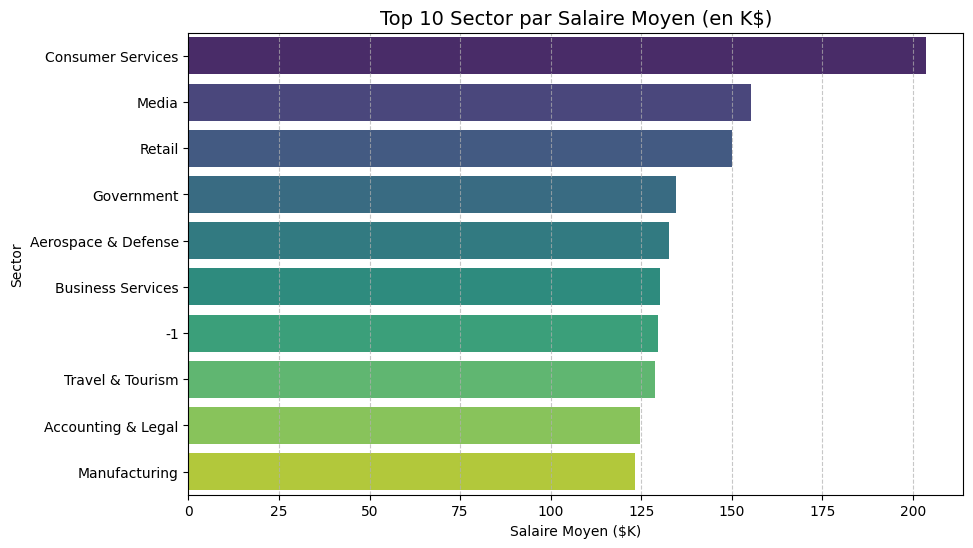

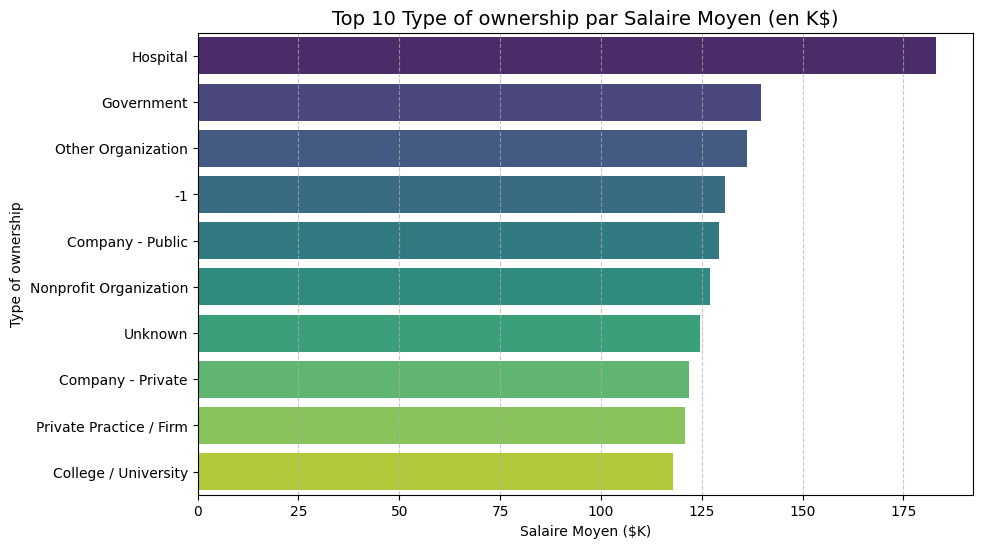

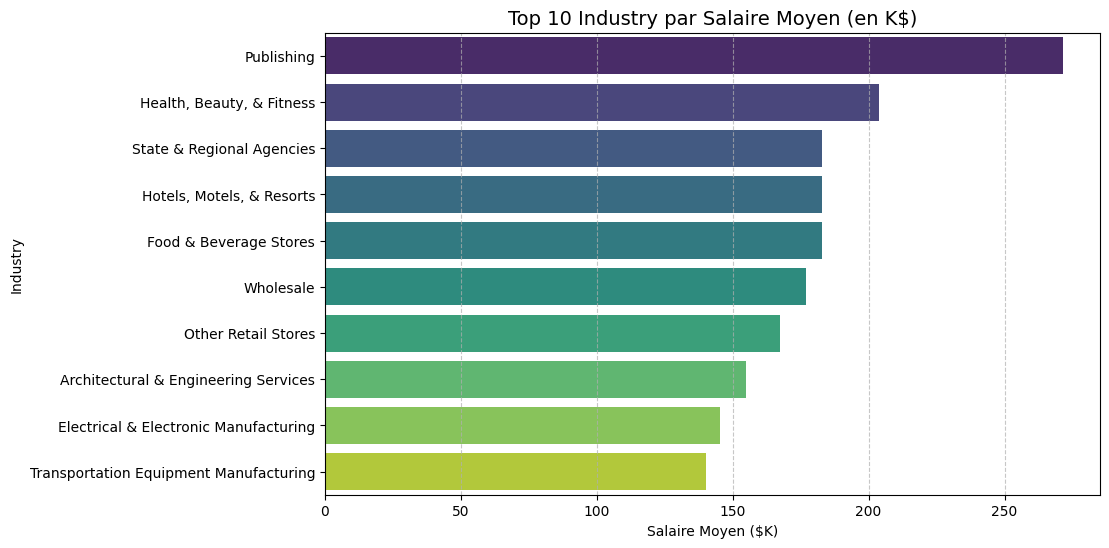

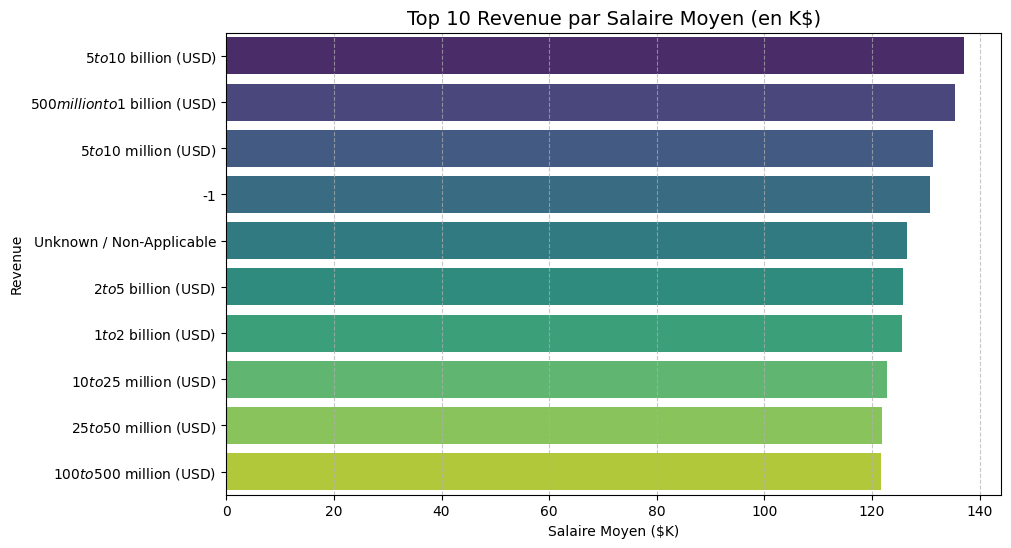

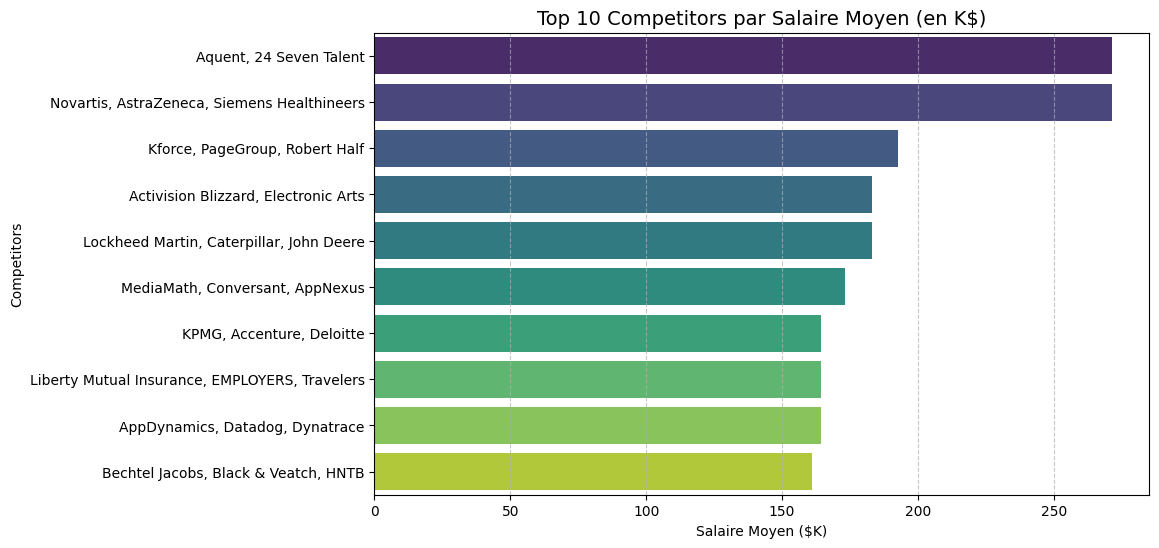

In [11]:

def plot_top_salaries(df, columns):
    for col in columns:
        plt.figure(figsize=(10, 6))
        
        # Calcul de la moyenne par catégorie
        top_salaries = df.groupby(col)['avg_salary'].mean().sort_values(ascending=False).head(10)

        sns.barplot(
            x=top_salaries.values, 
            y=top_salaries.index, 
            hue=top_salaries.index, 
            palette='viridis', 
            legend=False            
        )
        
        plt.title(f"Top 10 {col} par Salaire Moyen (en K$)", fontsize=14)
        plt.xlabel("Salaire Moyen ($K)")
        plt.ylabel(col)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.show()

cols_to_analyze = ['Job Title','Salary Estimate','Company Name', 'Location','Headquarters',\
                  'Size', 'Sector','Type of ownership', 'Industry','Revenue','Competitors']

plot_top_salaries(df, cols_to_analyze)

### Analyse statistique (Test Anova)

In [12]:
import scipy.stats as stats

def run_anova(df, categorical_cols, target='avg_salary'):
    results = {}
    for col in categorical_cols:
        groups = [group[target].values for name, group in df.groupby(col)]
        f_stat, p_val = stats.f_oneway(*groups)
        results[col] = p_val
    
    # Un p-value < 0.05 signifie que la variable est significative
    return pd.Series(results).sort_values()

cols_cat = df.select_dtypes(include=['object','string']).columns.tolist()

anova_results = run_anova(df, cols_cat)

print("ANOVA p-values (Plus c'est petit, plus c'est influent) :")
print(anova_results)

ANOVA p-values (Plus c'est petit, plus c'est influent) :
Salary Estimate      0.000000
Sector               0.004625
Industry             0.030308
Revenue              0.105792
Type of ownership    0.114871
Size                 0.319643
Location             0.643262
Job Title            0.665340
Headquarters         0.696297
Company Name         0.699980
Job Description      0.767202
Competitors          0.907238
dtype: float64


## Nettoyage des données

In [13]:
# Compter les -1 par colonne
missing_counts = (df == -1).sum() + (df == '-1').sum()
print(missing_counts[missing_counts > 0])

Rating                50
Headquarters          31
Size                  27
Founded              118
Type of ownership     27
Industry              71
Sector                71
Revenue               27
Competitors          501
dtype: int64


In [14]:

for col in ['Rating', 'Founded']:
    df[col] = df[col].replace(['-1', -1], np.nan)

In [15]:
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

In [16]:
cols_catg = ['Headquarters', 'Size', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors']

for col in cols_catg:
    df[col] = df[col].replace(['-1', -1, 'Unknown / Non-Applicable'], 'Unknown')


In [17]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df_final = remove_outliers(df, 'avg_salary')
print(f"Nombre de lignes après nettoyage : {len(df_final)}")

Nombre de lignes après nettoyage : 631


## features engineering

#### Transformation de la variable temporelle : Calcul de l'ancienneté des entreprises (company_age)

In [18]:
current_year = 2026
df['company_age'] = df['Founded'].apply(lambda x: current_year - x if x > 0 else np.nan)
df['company_age'] = df['company_age'].fillna(df['company_age'].median())

#### Extraction Feature : Catégorisation des entreprises à partir de company_age

In [19]:
def categorize_age(age):
    if age < 5: return 'Startup'
    elif age < 15: return 'Scale-up'
    elif age < 50: return 'Established'
    else: return 'Legacy'

df['company_type'] = df['company_age'].apply(categorize_age)

#### Extraction Feature : Conversion du chiffre d'affaires(Revenue) en revenue_rank 

In [20]:
def revenue_level(val):
    val = str(val).lower()
    if 'billion' in val:
        return 2  
    if 'million' in val:
        return 1 
    return 0      

df['revenue_rank'] = df['Revenue'].apply(revenue_level)

In [21]:
print(df.groupby('revenue_rank')['avg_salary'].mean())

revenue_rank
0    126.977083
1    119.358238
2    125.584795
Name: avg_salary, dtype: float64


#### Extraction Feature : Transformation de la variable Size en rangs numériques

In [22]:
def scale_company_size(size_val):
    size_val = str(size_val).lower()
    
    # On définit des paliers simples basés sur les mots-clés
    if '10000+' in size_val:
        return 4  # Très grande
    if '5001 to 10000' in size_val or '1001 to 5000' in size_val:
        return 3  # Grande
    if '501 to 1000' in size_val or '201 to 500' in size_val:
        return 2  # Moyenne
    if '51 to 200' in size_val or '1 to 50' in size_val:
        return 1  # Petite
        
    return 0  # Unknown 

df['size_score'] = df['Size'].apply(scale_company_size)

print(df.groupby('size_score')['avg_salary'].mean())

size_score
0    135.659091
1    124.529412
2    119.904321
3    123.569697
4    122.481250
Name: avg_salary, dtype: float64


#### Feature Extraction : Transformation des titres de postes en rangs de séniorité

In [23]:
def extract_seniority(title):
    title = str(title).lower()
   
    leadership = ['principal', 'vp', 'director', 'head', 'lead', 'staff', 'manager']
    seniors = ['senior', 'sr', 'iii', 'iv']
    juniors = ['junior', 'jr', 'entry', 'associate', 'intern']

    if any(word in title for word in leadership):
        return 1
    if any(word in title for word in seniors):
        return 2
    if any(word in title for word in juniors):
        return 3
        
    return 4 # Mid-level 


df['seniority_score'] = df['Job Title'].apply(extract_seniority)

#### Feature Extraction : Extraction de l'État (Location)


In [24]:

df['job_state'] = df['Location'].apply(lambda x: x.split(',')[-1].strip() if ',' in str(x) else x)

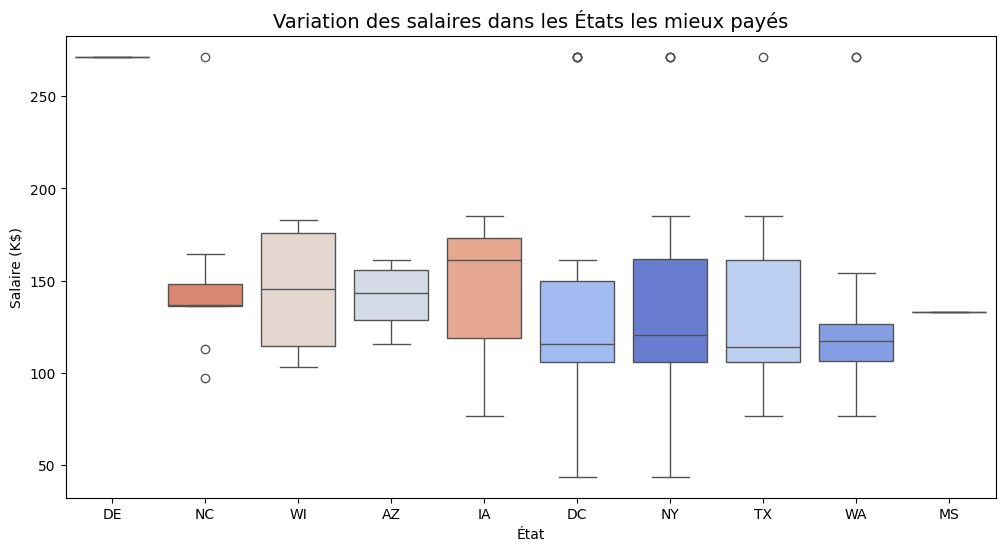

job_state
DE    271.500000
NC    150.111111
WI    144.416667
AZ    140.875000
IA    140.833333
DC    139.500000
NY    136.432692
TX    136.058824
WA    134.781250
MS    133.000000
Name: avg_salary, dtype: float64


In [25]:
state_avg = df.groupby('job_state')['avg_salary'].mean().sort_values(ascending=False).head(10)
top_states_list = state_avg.index.tolist()

df_top = df[df['job_state'].isin(top_states_list)]


plt.figure(figsize=(12, 6))
sns.boxplot(
    x='job_state', 
    y='avg_salary', 
    data=df_top, 
    order=top_states_list, 
    palette='coolwarm',
    hue='job_state', 
    legend=False      
)

plt.title('Variation des salaires dans les États les mieux payés', fontsize=14)
plt.ylabel('Salaire (K$)')
plt.xlabel('État')
plt.show()
print(state_avg)

#### Extraction Feature : Mapping des Job Title vers des familles de métiers

In [26]:
def categorize_role(title):
    title = str(title).lower()
    if 'data scientist' in title or 'scientist' in title:
        return 'Data Scientist'
    if 'analyst' in title or 'analytics' in title:
        return 'Data Analyst'
    if 'engineer' in title or 'mle' in title:
        return 'Data Engineer / MLE'
    if 'manager' in title or 'director' in title or 'head' in title:
        return 'Manager / Director'
    return 'Other'

df['job_role'] = df['Job Title'].apply(categorize_role)


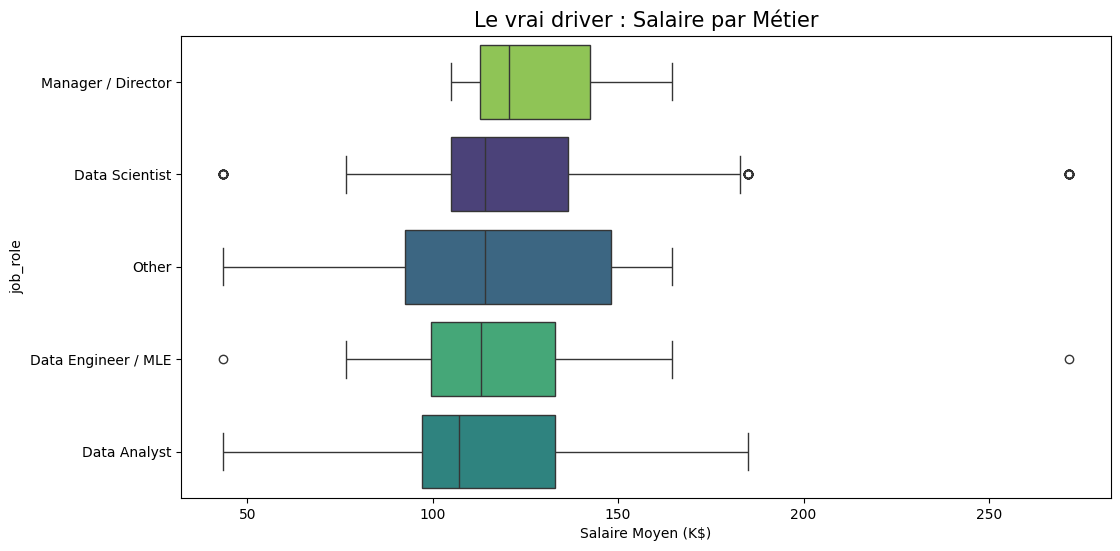

job_role
Manager / Director     130.000000
Data Scientist         125.886320
Other                  120.538462
Data Engineer / MLE    116.381944
Data Analyst           114.315385
Name: avg_salary, dtype: float64


In [27]:

plt.figure(figsize=(12, 6))
order = df.groupby('job_role')['avg_salary'].mean().sort_values(ascending=False).index

sns.boxplot(x='avg_salary', y='job_role', data=df, order=order, palette='viridis', hue='job_role', legend=False)
plt.title("Le vrai driver : Salaire par Métier", fontsize=15)
plt.xlabel("Salaire Moyen (K$)")
plt.show()
print(df.groupby('job_role')['avg_salary'].mean().sort_values(ascending=False))

#### Table de pivotement : Distribution du salaire moyen  et effectifs par binôme Job Role / Job State

In [28]:
top_10_states = df.groupby('job_state')['avg_salary'].mean().sort_values(ascending=False).head(10).index
df_top_states = df[df['job_state'].isin(top_10_states)]

pivot_table = df_top_states.pivot_table(
    values='avg_salary', 
    index='job_state', 
    columns='job_role', 
    aggfunc='mean'
).fillna(0)

print(pivot_table)

job_role   Data Analyst  Data Engineer / MLE  Data Scientist  Other
job_state                                                          
AZ             0.000000           115.500000      149.333333   0.00
DC           133.000000             0.000000      139.760000   0.00
DE             0.000000             0.000000      271.500000   0.00
IA           140.833333             0.000000        0.000000   0.00
MS             0.000000             0.000000      133.000000   0.00
NC           105.000000           149.666667      173.000000   0.00
NY           134.750000           135.000000      139.284091  78.25
TX           138.500000             0.000000      135.535714   0.00
WA           105.000000             0.000000      136.766667   0.00
WI           154.000000             0.000000      142.500000   0.00


#### Distribution du salaire moyen par rapport aux Features catégorielles transformées.

/tmp/ipykernel_6195/4161779294.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, vert=False, patch_artist=True,


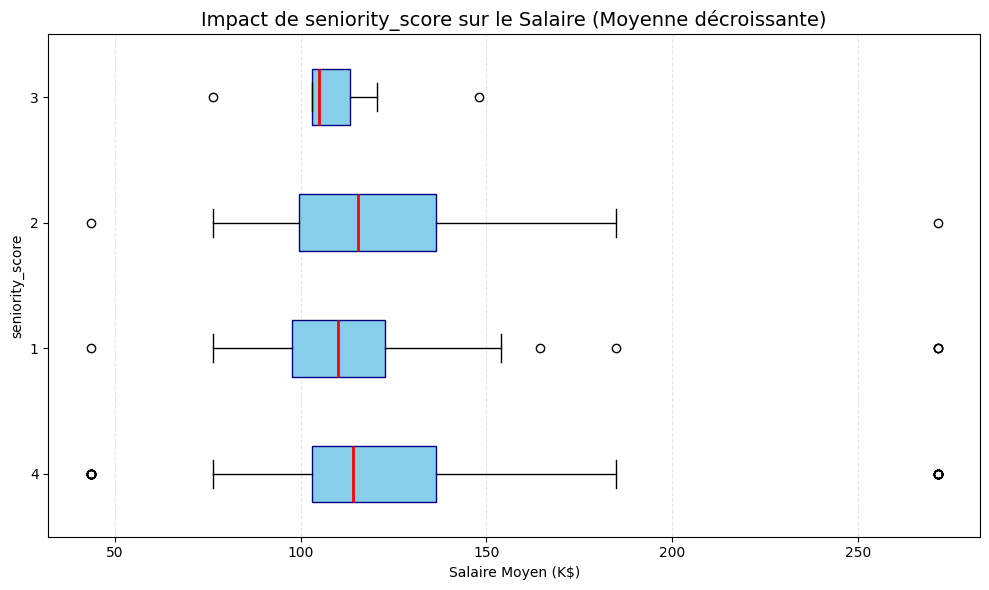

/tmp/ipykernel_6195/4161779294.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, vert=False, patch_artist=True,


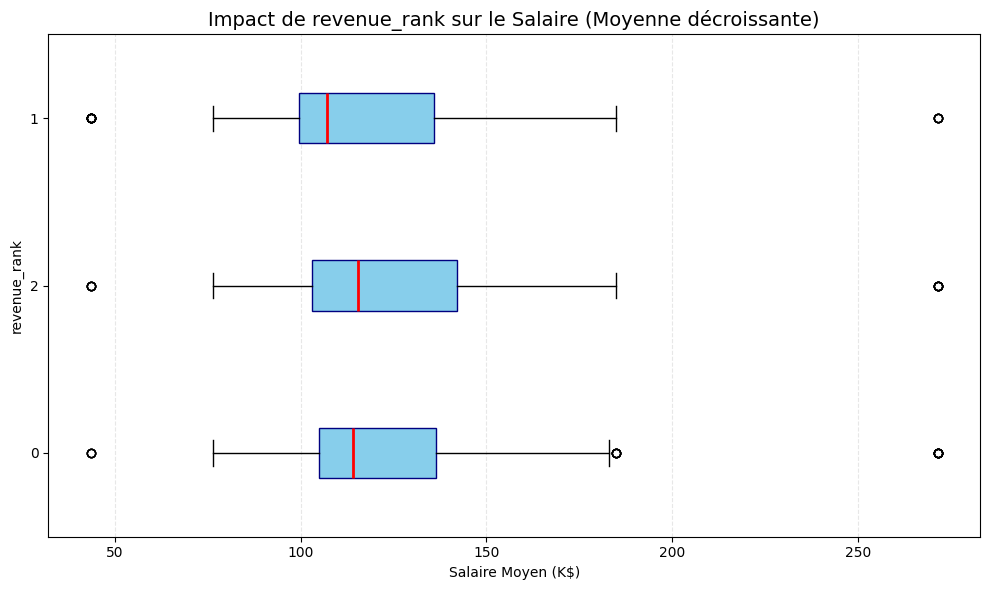

/tmp/ipykernel_6195/4161779294.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, vert=False, patch_artist=True,


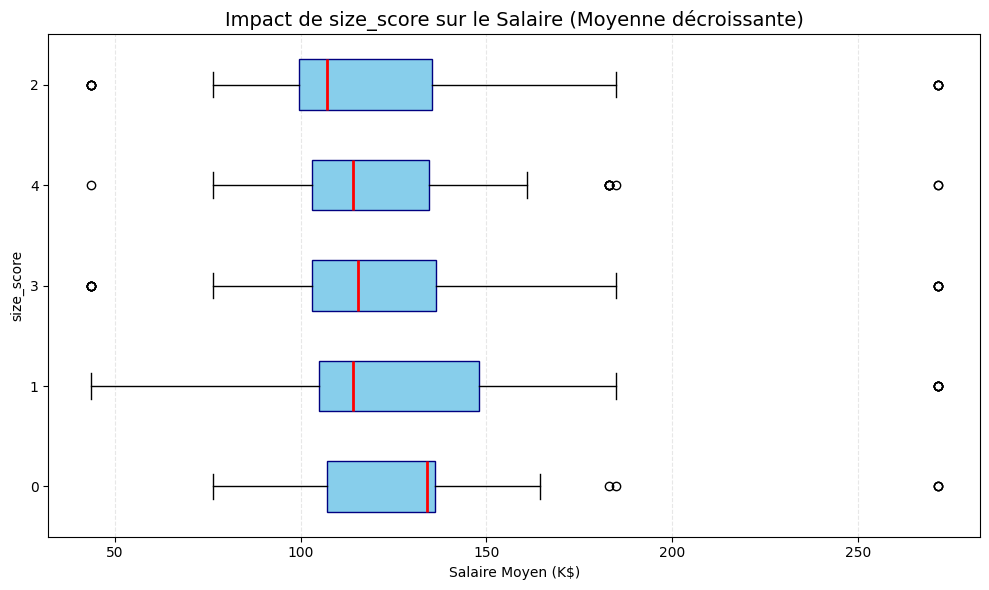

/tmp/ipykernel_6195/4161779294.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, vert=False, patch_artist=True,


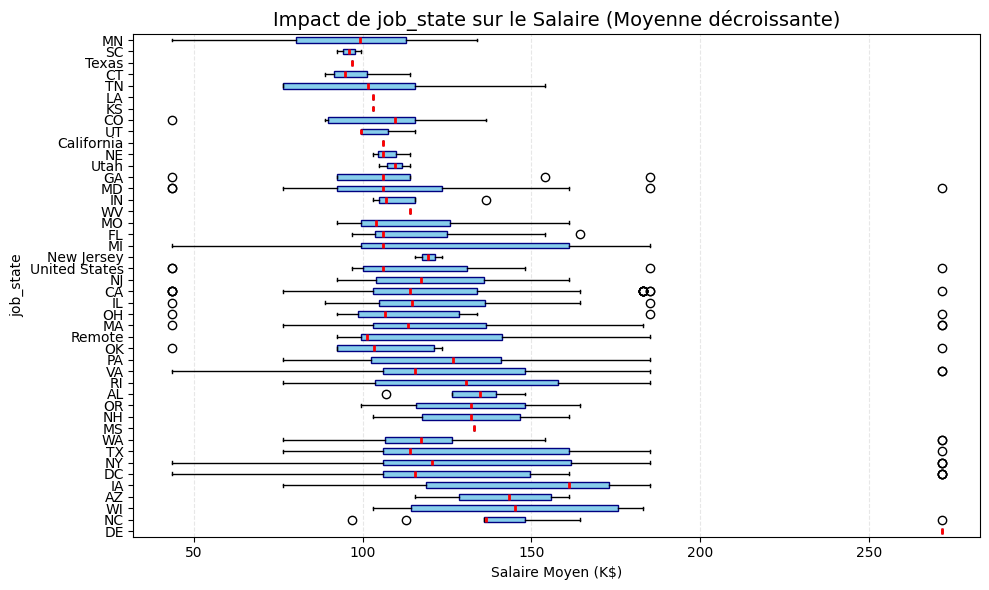

/tmp/ipykernel_6195/4161779294.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, vert=False, patch_artist=True,


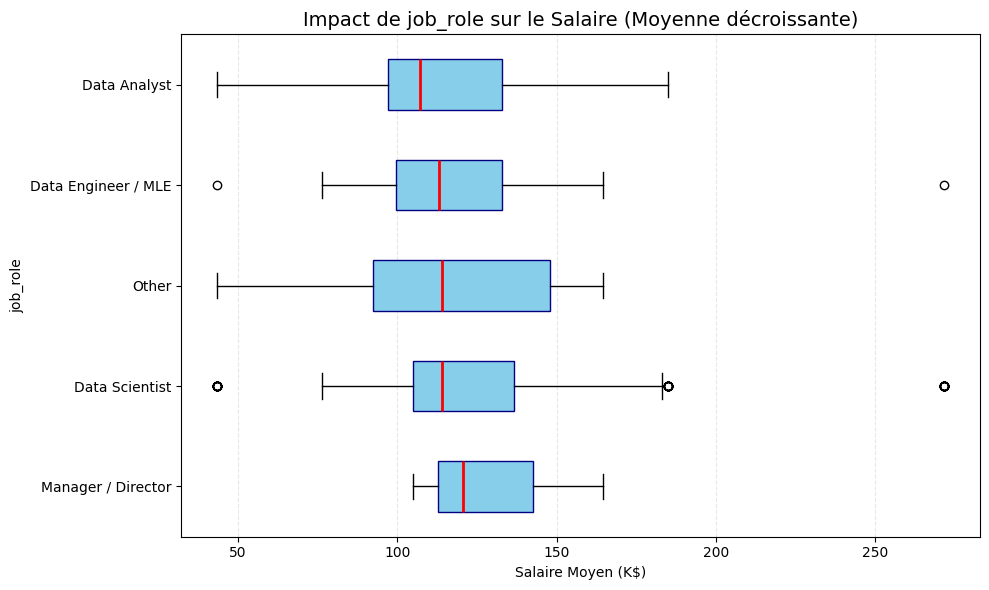

In [29]:

def plot_boxplot(df):
    cols_cat = ['seniority_score', 'revenue_rank', 'size_score','job_state','job_role']
    
    for col in cols_cat:
        categories = df.groupby(col)['avg_salary'].mean().sort_values(ascending=False).index
        data_to_plot = [df[df[col] == cat]['avg_salary'] for cat in categories]
        
        plt.figure(figsize=(10, 6))
        plt.boxplot(data_to_plot, vert=False, patch_artist=True, 
                    labels=categories,
                    boxprops=dict(facecolor='skyblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
        
        plt.title(f"Impact de {col} sur le Salaire (Moyenne décroissante)", fontsize=14)
        plt.xlabel("Salaire Moyen (K$)")
        plt.ylabel(col)
        plt.grid(axis='x', linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_boxplot(df)

In [30]:
cols_cat = df.select_dtypes(include=['object','string']).columns.tolist()

anova_results = run_anova(df, cols_cat)

print("ANOVA: Analyse de l'importance des features extraite")
print(anova_results)

ANOVA: Analyse de l'importance des features extraite
Salary Estimate      0.000000
Sector               0.004625
Industry             0.030308
Revenue              0.081076
Type of ownership    0.082642
job_role             0.096518
job_state            0.115962
Size                 0.313574
Location             0.643262
Job Title            0.665340
Headquarters         0.696297
Company Name         0.699980
Job Description      0.767202
Competitors          0.907238
company_type         0.985950
dtype: float64


In [40]:
cols_cat = ['seniority_score', 'revenue_rank', 'size_score','job_state','job_role','company_type']

anova_results = run_anova(df, cols_cat)

print("ANOVA: Analyse de l'importance des features extraite")
print(anova_results)

ANOVA: Analyse de l'importance des features extraite
revenue_rank       0.075109
job_role           0.096518
job_state          0.115962
size_score         0.224394
seniority_score    0.761661
company_type       0.985950
dtype: float64


<Axes: >

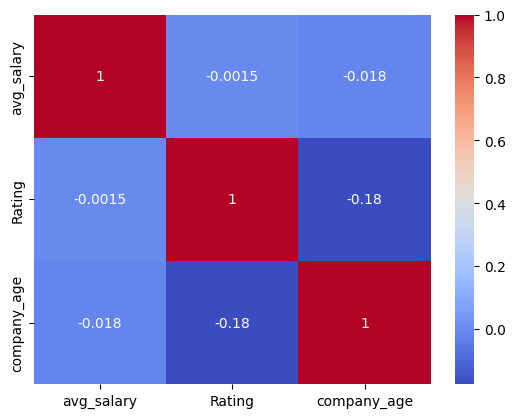

In [32]:
cols_catg = ["avg_salary","Rating","company_age"]
correlation_matrix = df[cols_catg].corr()

# Visualisation avec une Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

In [41]:

print(df['avg_salary'].describe())
print(df['avg_salary'].value_counts().head())

count    672.000000
mean     123.663690
std       39.580268
min       43.500000
25%      103.000000
50%      114.000000
75%      136.500000
max      271.500000
Name: avg_salary, dtype: float64
avg_salary
92.5     43
107.0    43
114.0    41
106.0    39
103.0    32
Name: count, dtype: int64


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          672 non-null    str    
 1   Salary Estimate    672 non-null    str    
 2   Job Description    672 non-null    str    
 3   Rating             672 non-null    float64
 4   Company Name       672 non-null    str    
 5   Location           672 non-null    str    
 6   Headquarters       672 non-null    str    
 7   Size               672 non-null    str    
 8   Founded            554 non-null    float64
 9   Type of ownership  672 non-null    str    
 10  Industry           672 non-null    str    
 11  Sector             672 non-null    str    
 12  Revenue            672 non-null    str    
 13  Competitors        672 non-null    str    
 14  avg_salary         672 non-null    float64
 15  company_age        672 non-null    float64
 16  company_type       672 non-null    st

In [37]:
output_path = "../data/raw/cleaned_data2.csv"
df_final = df
    # Sauvegarder le DataFrame
df_final.to_csv(output_path, index=False, encoding='utf-8')

### Synthèse de la Sélection de Features

 #### 1. Features Conservées 
 - Secteur & Industrie ($p < 0.05$) : Déterminants majeurs du budget salarial.
 -  Job Role ($p \approx 0.09$) : Différencie les échelles de rémunération par métier.
 - Job State ($p \approx 0.11$) : Capture les écarts liés à la localisation géographique.
 - Revenue Rank ($p \approx 0.07$) : Reflète la capacité financière de l'entreprise.

#### 2. Features écartées
- Rating (Corr $\approx -0.0015$) : Aucune relation linéaire détectée entre la note de l'entreprise et le salaire.
- Seniority Score ($p > 0.70$) : Dans ce dataset, l'intitulé "Senior" ne garantit pas statistiquement un salaire plus élevé.
- Type of Ownership ($p > 0.08$) : Trop de redondance avec le secteur d'activité et signal trop faible.
- Company Name & Location & Founded: Cardinalité trop élevée (trop de valeurs uniques) risquant de provoquer du surapprentissage (overfitting).